### Building RAG 

In [1]:
## Import warnings 
import warnings 
warnings.filterwarnings('ignore')

# PDF loader 
from langchain_community.document_loaders import PyPDFLoader 
loader = PyPDFLoader('economics_research_reference.pdf')
pages = loader.load()

# Split data 
from langchain_text_splitters import RecursiveCharacterTextSplitter
spliter = RecursiveCharacterTextSplitter(chunk_size=1200,chunk_overlap=150)
text_split = spliter.split_documents(pages)
# chunks 
chunks = [i.page_content for i in text_split]
metadata = [i.metadata for i in text_split]

# Create unique ids 
import hashlib 
ids =[hashlib.md5(chunk.encode('utf-8')).hexdigest() for chunk in chunks]

# CromaDB create 
import chromadb
from chromadb.utils.embedding_functions import DefaultEmbeddingFunction

embedding_fun = DefaultEmbeddingFunction()
client = chromadb.PersistentClient(path="./Vector_DataBase")

collection = client.get_or_create_collection(
    name="Research_agent",
    embedding_function=embedding_fun
)
if collection.count()!= len(chunks):
    collection.add(
    documents=chunks,
    ids=ids
    )

    
collection.count()

22

### State Define 

In [2]:
from langgraph.graph import StateGraph , START , END 
from typing import TypedDict

class Self(TypedDict):
    query : str 
    context : list[str]
    grounded : bool 
    answer : str 
    needed_grounded : str 
    retry : int 

### Retrival Argumented Generation 

In [3]:
from rank_bm25 import BM25Okapi 
tokens = [i.lower().split() for i in chunks]
token_corpus = BM25Okapi(tokens)



# RAG building 
def Retrival_Fetch(state:Self):
    query = state['query'] 
    
    result = collection.query(query_texts=[query],n_results=3)
    documents = result['documents'][0]
    distances = result['distances'][0]
    
    threshold = 1.0 
    
    dense_chunks = []
    for dist, doc in zip(distances, documents):
        if dist < threshold:
            dense_chunks.append(doc)
            
    scores = token_corpus.get_scores(query.lower().split())
    def get_index(score, k=10):
        indexed = list(enumerate(score))
        sorted_indices = sorted(indexed, key=lambda x: x[1], reverse=True)
        return [idx for idx, scr in sorted_indices[:k] if scr > 0]


    keyword_corpus= get_index(score=scores,k=10)
    chunks_corpus = [chunks[i] for i in keyword_corpus]
    
    rrf_tokens = {}
    for rank , doc in enumerate(dense_chunks):
        rrf_tokens[doc] = rrf_tokens.get(doc,0.0)+1.0/(rank+60)
    for rank , doc in enumerate(chunks_corpus):
        rrf_tokens[doc] = rrf_tokens.get(doc,0.0)+1.0/(rank+60) 
        
    marge = sorted(rrf_tokens.items(),key=lambda x:x[1],reverse=True)
    
    top_docs = [i for i , doc in marge[:5]] 
    retry_time = state.get('retry',0)
    return {
        'context':top_docs ,
        'retry':retry_time+1
    }

### Import large language Model 

In [4]:
# LLM connection 
import os 
from langchain_groq import ChatGroq 
from dotenv import load_dotenv 
load_dotenv()
os.getenv('GROQ_API_KEY')
LLM = ChatGroq(model='openai/gpt-oss-120b')
LLM.invoke("hii?").content

'Hey there! 👋 How can I help you today?'

### Connection with LLM 

In [5]:
def LLM_connection(state:Self):
    prompt = f""" 
    context : {state['context']}
    question : {state['query']}
    """
    response = LLM.invoke(prompt)
    return {
        'answer':response
    }

### Finding Grounded 

In [6]:
def Grounded(state:Self):
    prompt = f"""
    Check whether the answer is supported by the provided context.

    Context:
    {state['context']}

    Question:
    {state['query']}

    Answer:
    {state['answer']}

    Return only:
    YES
    or
    NO
    """
    response = LLM.invoke(prompt).content
    result = response.strip().upper()
    
    return {
        "grounded": "YES" in result
    }

    
def check_grounded(state:Self):
    if state['grounded']:
        return 'end'
    elif state['retry']>=2:
        return 'end'
    else :
        return 'retry'
        

### Graph connection 

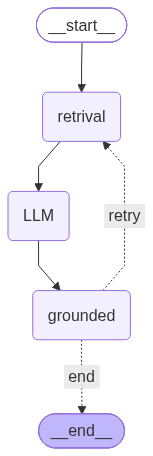

In [7]:
Builder = StateGraph(Self)

# Connection [create Node]
Builder.add_node('retrival',Retrival_Fetch)
Builder.add_node('LLM',LLM_connection)
Builder.add_node('grounded',Grounded)

# Create Edge 
Builder.add_edge(START,'retrival')
Builder.add_edge('retrival','LLM')
Builder.add_edge('LLM','grounded')
Builder.add_conditional_edges(
    'grounded',check_grounded,
    {
        'end':END , 
        'retry':'retrival'
    }
)
graph = Builder.compile()
graph 

### Testing 

In [ ]:
question = "What is the Full form of LLM?"
result = graph.invoke({'query':question , 'retry':0})
result['answer']

AIMessage(content='**LLM** stands for **Large Language Model**.', additional_kwargs={'reasoning_content': 'The user provides a context that is a list of economics notes, then asks: "What is the Full form of LLM?" They likely refer to "LLM" abbreviation. In context of economics? But LLM could be "Large Language Model" in AI. Could also be "Master of Laws" (Legum Magister). Since the context is economics, but the question is generic. Likely they want "Large Language Model". Provide answer.\n\nWe should answer concisely.'}, response_metadata={'token_usage': {'completion_tokens': 121, 'prompt_tokens': 1179, 'total_tokens': 1300, 'completion_time': 0.254844552, 'completion_tokens_details': {'reasoning_tokens': 100}, 'prompt_time': 0.058010793, 'prompt_tokens_details': None, 'queue_time': 0.3189796, 'total_time': 0.312855345}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_c800245357', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': '